In [1]:
%pip install contextily shapely geopandas

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import contextily as ctx
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
from shapely.geometry import Point

# 1. Load data and setup the 33 relevant stations
print("Reading raw Parquet file...")
df = pd.read_parquet("../../data/knmi_fh_fx_all.parquet")

reliable_stations = [
    "AMSTERDAM/SCHIPHOL AP",
    "DEELEN",
    "ROTTERDAM THE HAGUE AP",
    "MAASTRICHT AACHEN AP",
    "GRONINGEN AP EELDE",
    "VLISSINGEN AWS",
    "DE BILT AWS",
    "DE KOOY VK",
    "GILZE RIJEN",
    "EINDHOVEN AP",
    "LELYSTAD AP",
    "HERWIJNEN AWS",
    "TWENTHE AWS",
    "MARKNESSE AWS",
    "HUPSEL AWS",
    "VOLKEL",
    "NIEUW BEERTA AWS",
    "LEEUWARDEN",
    "CABAUW TOWER AWS",
    "ARCEN AWS",
    "IJMUIDEN WP",
    "HOEK VAN HOLLAND AWS",
    "LICHTEILAND GOEREE",
    "ROTTERDAM GEULHAVEN",
    "LAUWERSOOG AWS",
    "HEINO AWS",
    "STAVOREN AWS",
    "WESTDORPE AWS",
    "HOOGEVEEN AWS",
    "OOSTERSCHELDE 4",
    "CADZAND WP",
    "OOSTERSCHELDE WP",
    "HUIBERTGAT WP",
]

print("Validating permanent WMO station identification codes...")
# Extract the unique, unshifting WMO tracking IDs tied to your specific station subset
reliable_ids = df[df["stationname"].isin(reliable_stations)]["station"].unique()

# Isolate unique geographic records using WMO keys to bypass 2025/2026 text anomalies
stations_geo = df[df["station"].isin(reliable_ids)].drop_duplicates(subset=["station"]).copy()

# Re-map clean historical names back to WMO keys for map labelling consistency
id_to_name_map = (
    df[df["stationname"].isin(reliable_stations)]
    .drop_duplicates(subset=["station"])
    .set_index("station")["stationname"]
    .to_dict()
)
stations_geo["display_name"] = stations_geo["station"].map(id_to_name_map)

# Strictly enforce original ranking order (1 to 33) based on your reliability criteria
stations_geo["display_name"] = pd.Categorical(stations_geo["display_name"], categories=reliable_stations, ordered=True)
stations_geo = stations_geo.sort_values("display_name").reset_index(drop=True)

# 2. Convert to a GeoDataFrame
# Standard GPS coordinates use WGS84 (EPSG:4326)
geometry = [Point(xy) for xy in zip(stations_geo["lon"], stations_geo["lat"])]
gdf = gpd.GeoDataFrame(stations_geo, geometry=geometry, crs="EPSG:4326")

# Web maps (OpenStreetMap) use Web Mercator projection (EPSG:3857)
gdf = gdf.to_crs(epsg=3857)

# 3. Plotting the static PNG map
fig, ax = plt.subplots(figsize=(12, 14))

# Plot the station markers as solid blue circles
gdf.plot(ax=ax, color="darkblue", markersize=140, edgecolor="white", zorder=3)

# Add the index numbers (1 to 33) next to/on top of the pins
for idx, row in gdf.iterrows():
    # Offset text slightly so it sits cleanly right next to the point
    ax.annotate(
        text=str(idx + 1),
        xy=(row.geometry.x, row.geometry.y),
        xytext=(6, 4),
        textcoords="offset points",
        fontsize=11,
        fontweight="bold",
        color="black",
        bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="darkblue", alpha=0.85),
        zorder=4,
    )

# 4. Fetch and add the OpenStreetMap background
ctx.add_basemap(ax=ax, source=ctx.providers.OpenStreetMap.Mapnik, zorder=1)

# Clean up axes for a professional map look
ax.set_axis_off()
plt.title(
    "KNMI Weather Stations",
    fontsize=16,
    fontweight="bold",
    pad=20,
)
# add legenda on the right with numbers and station names
legend_labels = [f"{idx + 1}. {name}" for idx, name in enumerate(reliable_stations)]
legend_text = "\n".join(legend_labels)
plt.gcf().text(
    0.95,
    0.5,
    legend_text,
    fontsize=10,
    va="center",
    ha="left",
)


# 5. Save directly to PNG
plt.savefig("knmi_stations_map.png", dpi=700, bbox_inches="tight")
plt.close()

print(f"Static map containing all {len(gdf)} verified WMO stations successfully saved as 'knmi_stations_map.png'!")

Reading raw Parquet file...
Validating permanent WMO station identification codes...
Static map containing all 33 verified WMO stations successfully saved as 'knmi_stations_map.png'!


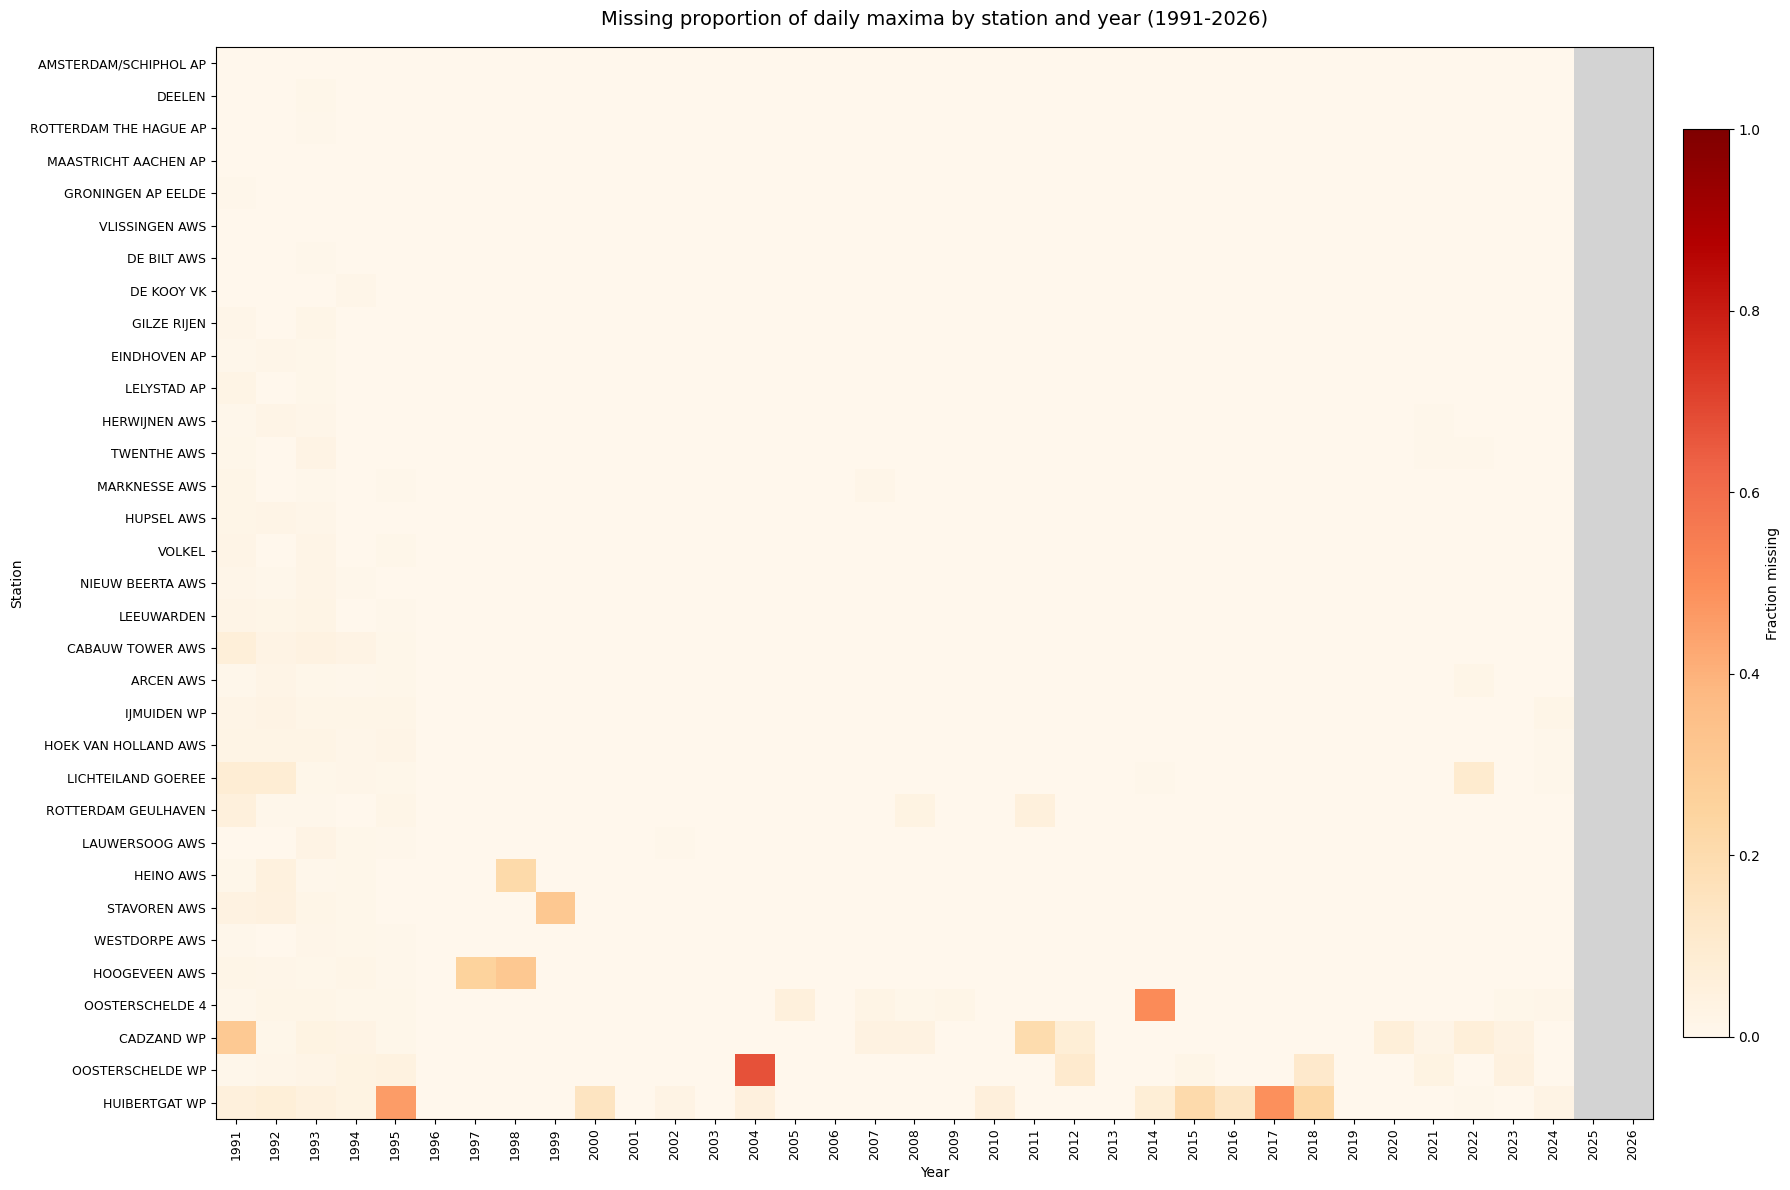

In [ ]:
import numpy as np

date_candidates = [
    c for c in df.columns if c.lower() in {"date", "datum", "datetime", "time", "yyyymmdd", "yyyymmddd"}
]
if not date_candidates:
    raise ValueError("No date-like column found in df")
date_col = date_candidates[0]

df["date"] = pd.to_datetime(df[date_col], errors="coerce")
df["year"] = df["date"].dt.year

daily_max_candidates = [c for c in df.columns if c.lower() in {"fx", "daily_max", "max", "maximum", "tmax", "tx"}]
if not daily_max_candidates:
    raise ValueError("No daily maxima column found in df")
daily_max_col = daily_max_candidates[0]

mask = (df["stationname"].isin(reliable_stations)) & (df["year"].between(1991, 2026))
missing_by_year = (
    df.loc[mask]
    .assign(missing=lambda d: d[daily_max_col].isna().astype(float))
    .groupby(["stationname", "year"])["missing"]
    .mean()
    .unstack(level=1)
    .reindex(index=reliable_stations, columns=range(1991, 2027))
)

heatmap_data = np.ma.masked_invalid(missing_by_year.values)

fig, ax = plt.subplots(figsize=(18, 12))
cmap = plt.cm.OrRd
cmap.set_bad("lightgray")

im = ax.imshow(heatmap_data, aspect="auto", cmap=cmap, vmin=0, vmax=1)

ax.set_xticks(np.arange(missing_by_year.shape[1]))
ax.set_xticklabels(missing_by_year.columns, rotation=90, fontsize=9)
ax.set_yticks(np.arange(missing_by_year.shape[0]))
ax.set_yticklabels(missing_by_year.index, fontsize=9)

ax.set_xlabel("Year")
ax.set_ylabel("Station")
ax.set_title("Missing proportion of daily maxima by station and year (1991-2026)", fontsize=14, pad=16)

cbar = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
cbar.set_label("Fraction missing")

plt.tight_layout()

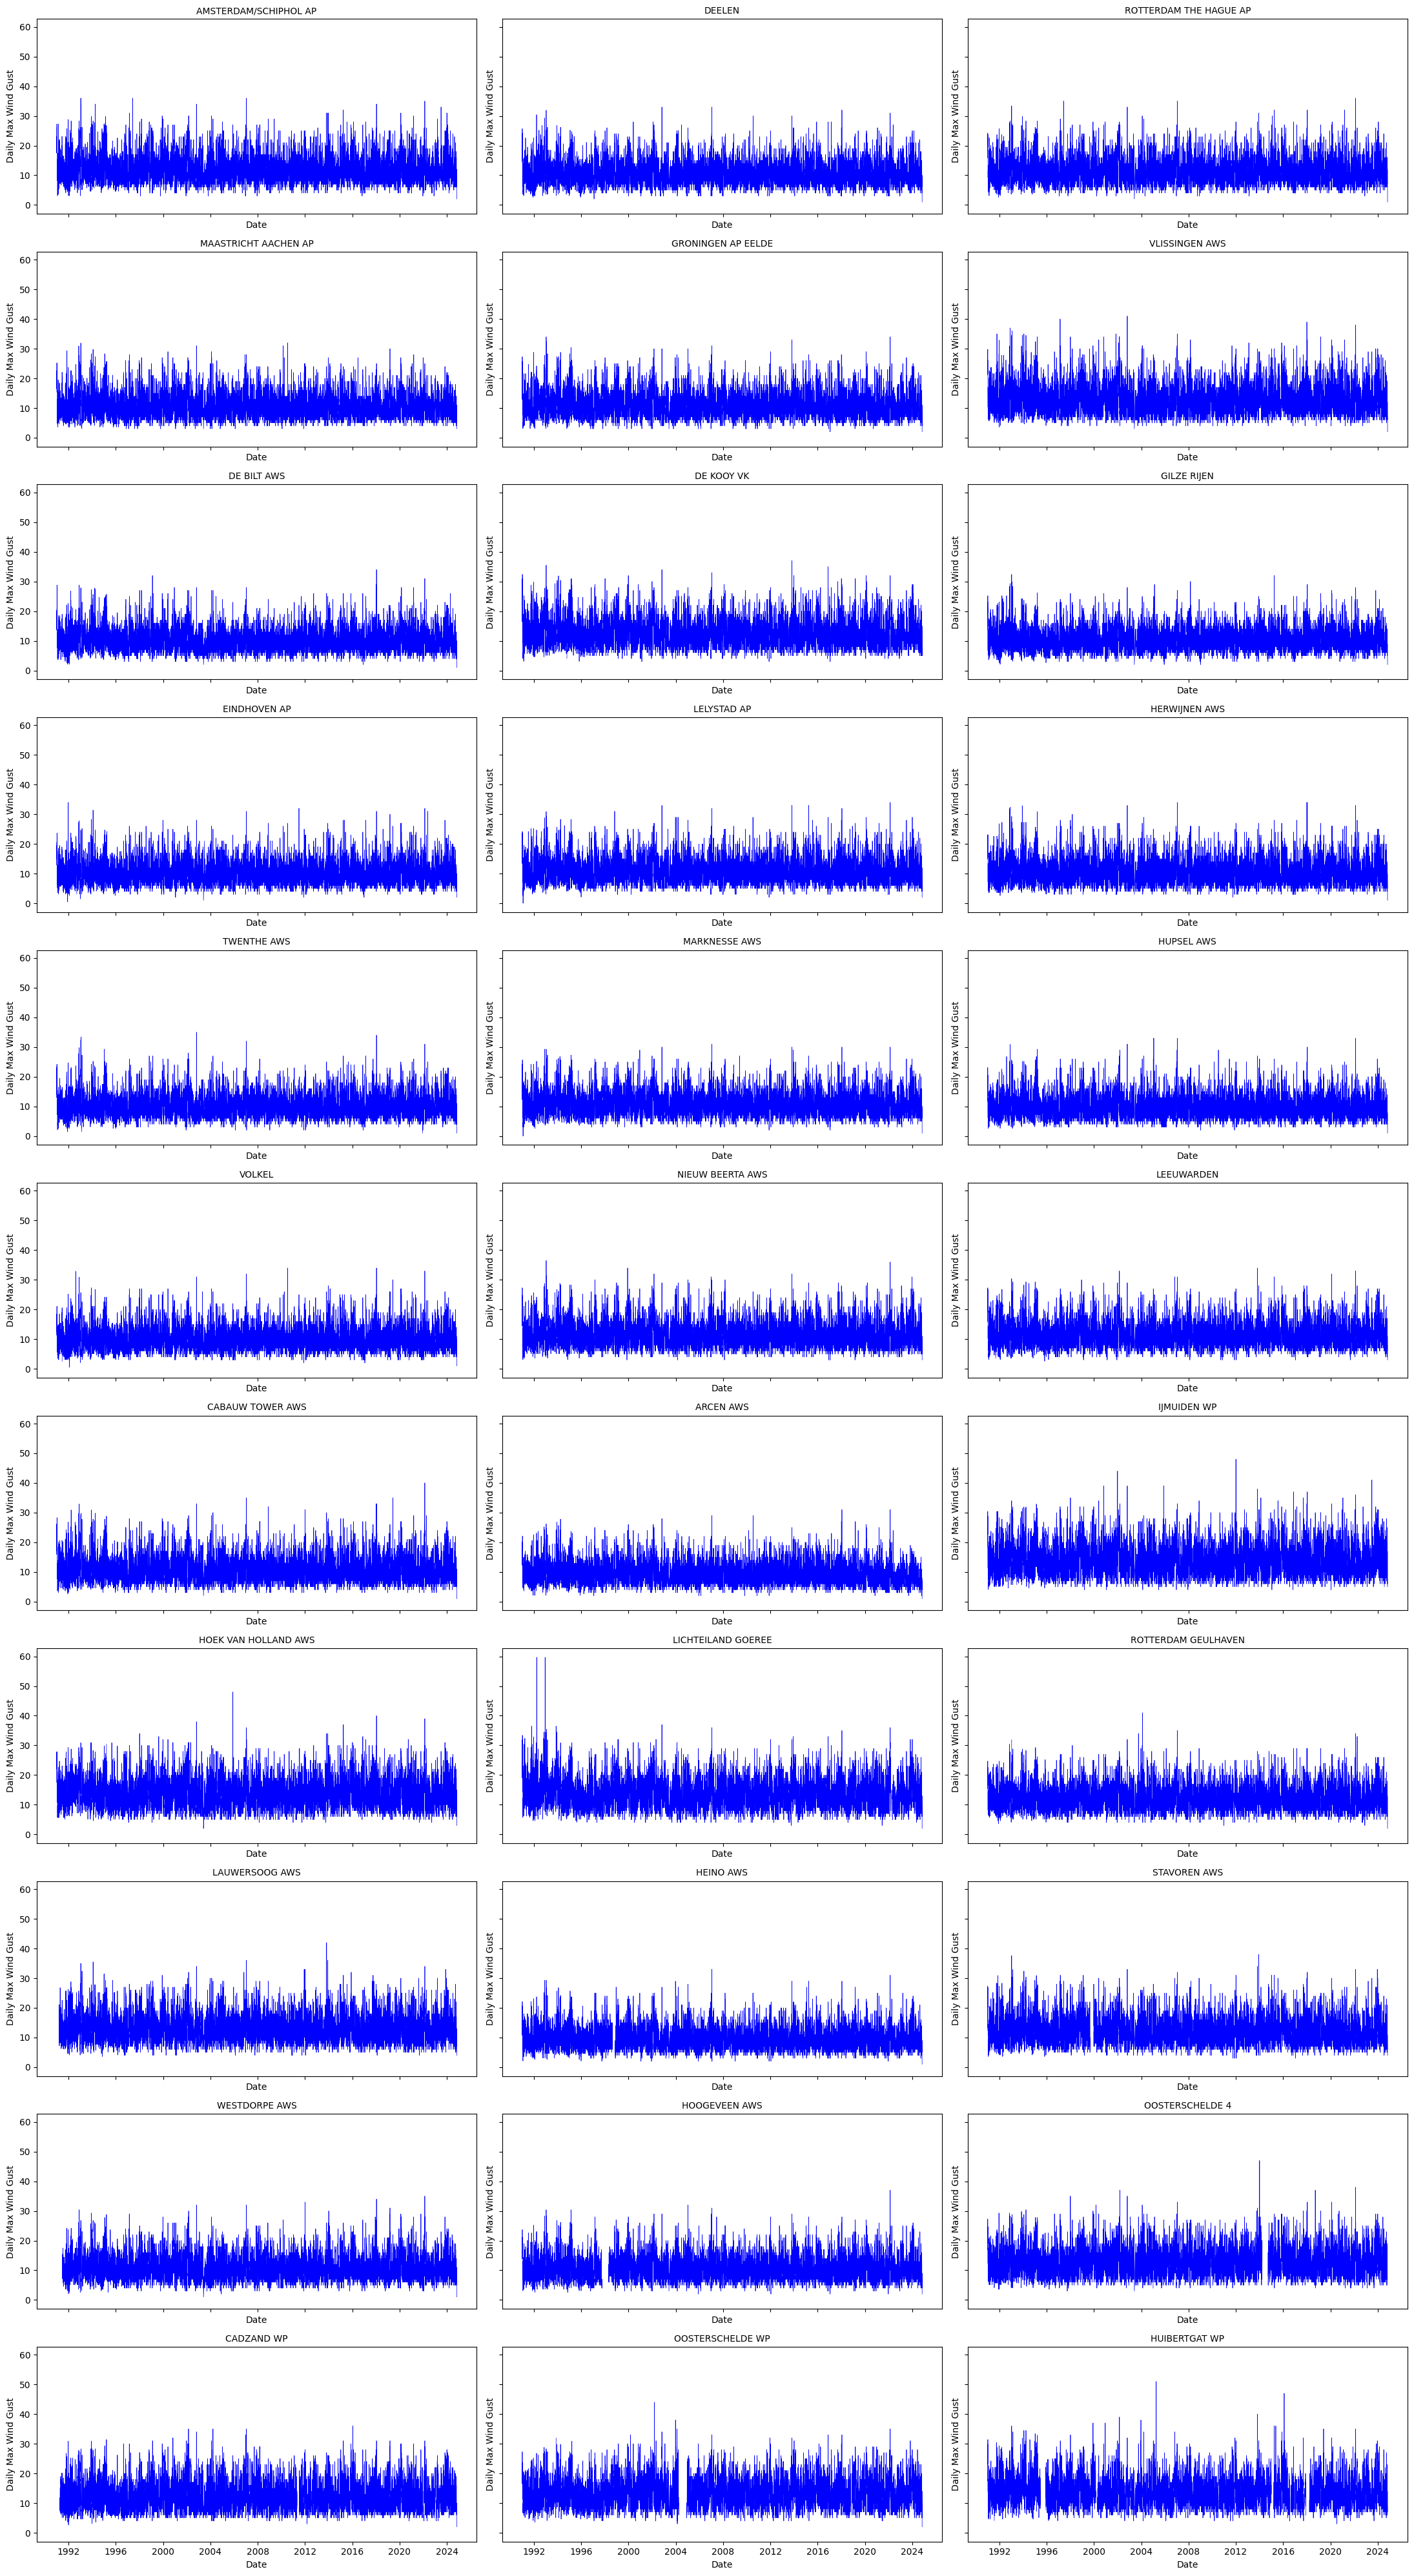

In [23]:
# plot a mosaic of the daily maximum time series for the 33 stations
# plot the maximum wind gusts for the 33 stations in a mosaic of time series, with one subplot per station, and the x-axis showing the date and the y-axis showing the daily maximum wind gusts
df_path = "../../data/knmi_daily_max_1991_2026.csv"
df = pd.read_csv(df_path)
df["date"] = pd.to_datetime(df["date"], errors="coerce")
# plot a mosaic of the daily maximum wind gusts for the 33 stations, with one subplot per station, and the x-axis showing the date and the y-axis showing the daily maximum wind gusts
fig, axes = plt.subplots(nrows=11, ncols=3, figsize=(22, 40), sharex=True, sharey=True)
for i, station in enumerate(reliable_stations):
    station_data = df[df["stationname"] == station]
    axes[i // 3, i % 3].plot(station_data["date"], station_data["FX"], color="blue", linewidth=0.5)
    axes[i // 3, i % 3].set_title(station, fontsize=10)
    axes[i // 3, i % 3].set_xlabel("Date")
    axes[i // 3, i % 3].set_ylabel("Daily Max Wind Gust")
plt.tight_layout()
plt.savefig("../../latex_project/figures/knmi_daily_max_mosaic.png", dpi=300)
plt.show()

In [19]:
df = pd.read_csv("../../data/filtered_station_metadata.csv")

# minimal distance in kilometers between the 33 stations
from geopy.distance import geodesic


def haversine_distance(coord1, coord2):
    return geodesic(coord1, coord2).kilometers


coords = list(zip(df["lat"], df["lon"]))
distances = []
for i in range(len(coords)):
    for j in range(i + 1, len(coords)):
        dist = haversine_distance(coords[i], coords[j])
        distances.append(dist)
min_distance = min(distances)
print(f"Minimum distance between the 33 stations: {min_distance:.2f} km")
# maximum distance in kilometers between the 33 stations
max_distance = max(distances)
print(f"Maximum distance between the 33 stations: {max_distance:.2f} km")

Minimum distance between the 33 stations: 12.00 km
Maximum distance between the 33 stations: 326.95 km
